In [1]:
import os


os.environ["RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO"] = "0"
os.environ["RAY_DEDUP_LOGS"] = "1"

In [16]:
# %%
import matplotlib.pyplot as plt
import numpy as np
import ray
import pandas as pd


from mpl_toolkits.mplot3d import Axes3D

from starforge.blackholes.parameters_recover.parameters_recovery import (
    ParametersRecoveryRemote
)

from starforge.blackholes.parameters_recover.metrics import (
    nrmse_percent,
    smape_percent,
    stabilized_mape_percent,
)

from starforge.blackholes.accretionrate.blackholesaccretionrate import (
    ParameterAccretionRate
)

from starforge.blackholes.parameters_recover.utils import (
    add_noise_to_data,
    gaussian_sum_from_p,
    make_bounds_for_gaussians,
)

from starforge.blackholes.parameters_recover.schemes import (
    GridParameters
)

In [3]:
if ray.is_initialized() is False:
    ray.init(ignore_reinit_error=True)

2026-05-19 09:09:58,284	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8266 


In [4]:
# ============================================================
# GRID
# ============================================================

mbh_steps = 25

grid_params = GridParameters(
    mbh_steps=mbh_steps,
    z_steps=mbh_steps * 100
)

ln_mbh_grid = np.linspace(
    grid_params.mbh_i,
    grid_params.mbh_f,
    grid_params.mbh_steps
)

In [5]:
# %%
# ============================================================
# BENCHMARK INITIAL CONDITION
# ============================================================

benchmark_params = np.array([
    3.3e-02,
    8.2e-03,
    5.4e-02,
    1.07e+01,
    1.29e+01,
    1.21e+01,
    6.93e-01,
    1.05e+00,
    7.47e-01
])

initial_condition = gaussian_sum_from_p(
    benchmark_params,
    ln_mbh_grid,
    n_gauss=3
)

In [6]:
# %%
# ============================================================
# PHYSICAL MODEL PARAMETERS
# ============================================================

accretion_params = ParameterAccretionRate(
    mbh_par=2e11,
    alpha_par=3e-1,
    tau_par=5e9,
    eta=0.1,
    t_q=1e9,
    b_1=0.1,
    b_2=0.1,
)

In [7]:
# ============================================================
# FORWARD SOLVER
# ============================================================

objective_function = ParametersRecoveryRemote.remote(
    grid_params=grid_params
)

In [8]:
# %%
# ============================================================
# REFERENCE FINAL BHMF
# ============================================================

reference_outputs = ray.get(
    objective_function.directly_problem.remote(
        initial_condition,
        accretion_params
    )
)

reference_final = reference_outputs.n_final

In [9]:
# ============================================================
# SYNTHETIC OBSERVATION
# ============================================================

noise_level = 0.10

target_data = add_noise_to_data(
    data=reference_final,
    mu=0.0,
    sigma=noise_level,
    rho=0.5,
    alpha=0.5,
    seed=52,
    noise_type='mixed'
)

In [10]:
# %%
# ============================================================
# OPTIMIZATION BOUNDS
# ============================================================

bounds = make_bounds_for_gaussians(
    x_min=6.0,
    x_max=15.0,
    preferred_center_index=2,
    preferred_center=12.0,
    preferred_center_radius=1.0,
    Amax=1e-1,
    sigma_min=0.01,
    sigma_max=5.0,
    sigma_max_preferred=1.0,
    K=3
)

bounds.extend([
    (0.5, 5.0),     # mbh_par
    (1.0, 10.0),    # tau_par
    (0.01, 0.6),    # alpha_par
    (0.01, 0.5),    # eta
    (0.5, 5.0),     # t_q
    (0.01, 0.5),    # b_1
    (0.01, 0.5),    # b_2
])

In [11]:
# %%
recovery = ParametersRecoveryRemote.remote(
    grid_params=grid_params
)

In [12]:
return_components = True

In [13]:
# %%
# ============================================================
# L-SURFACE COMPUTATION
# ============================================================

alpha_p_values = np.logspace(-5, 1, 10)
alpha_theta_values = np.logspace(-5, 1, 10)

results = []

for alpha_p in alpha_p_values:
    for alpha_theta in alpha_theta_values:

        print(
            f"Running optimization with "
            f"alpha_p={alpha_p:.2e}, "
            f"alpha_theta={alpha_theta:.2e}"
        )

        # ----------------------------------------------------
        # Optimization
        # ----------------------------------------------------

        best = ray.get(
            recovery.optimizer.remote(
                bounds=bounds,
                target_data=target_data,
                weight_p=alpha_p,
                weight_theta=alpha_theta,
                n_max=1
            )
        )

        # ----------------------------------------------------
        # Diagnostics
        # ----------------------------------------------------

        diagnostics = ray.get(
            recovery.objective_function.remote(
                np.array(best.x),
                target_data,
                weight_p=alpha_p,
                weight_theta=alpha_theta,
                return_components=True
            )
        )

        results.append({
            "alpha_p": alpha_p,
            "alpha_theta": alpha_theta,
            "objective": diagnostics["objective"],
            "misfit": diagnostics["misfit"],
            "R_p": diagnostics["R_p"],
            "R_theta": diagnostics["R_theta"],
            "best_parameters": np.array(best.x),
        })

Running optimization with alpha_p=1.00e-05, alpha_theta=1.00e-05
(ParametersRecovery pid=441261) Starting optimization ...
(ParametersRecovery pid=441261) Objective value: 1.205154e+00 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 6.803952e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 1.185618e-01 | Context: Minimum detected in annealing process


(ParametersRecovery pid=441261) /home/eduardo/Projects/starforge2/.venv/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
(ParametersRecovery pid=441261)   df = [f_eval - f0 for f_eval in f_evals]


(ParametersRecovery pid=441261) Objective value: 1.106964e-01 | Context: Detection occurred in local search
(ParametersRecovery pid=441261) Objective value: 1.028097e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 7.789167e-02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 5.441799e-02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 2.422711e-02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 1.658937e-02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Stage 1/1 | Best Objective: 1.658937e-02
(ParametersRecovery pid=441261) Optimization completed | Final Objective: 1.658937e-02
Running optimization with alpha_p=1.00e-05, alpha_theta=4.64e-05
(ParametersRecovery pid=441261) Starting optimization ...
(ParametersRecovery pid=441261) Objective value: 3.798

(ParametersRecovery pid=441261) /home/eduardo/Projects/starforge2/src/starforge/blackholes/parameters_recover/parameters_recovery.py:202: RuntimeWarning: invalid value encountered in log10
(ParametersRecovery pid=441261)   normalization_model = np.log10(params_array[-n:] + epsilon)


(ParametersRecovery pid=441261) Objective value: 1.418881e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 8.567124e-02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 3.884939e-02 | Context: Detection occurred in local search
(ParametersRecovery pid=441261) Stage 1/1 | Best Objective: 3.884939e-02
(ParametersRecovery pid=441261) Optimization completed | Final Objective: 3.884939e-02
Running optimization with alpha_p=1.00e-05, alpha_theta=2.15e-02
(ParametersRecovery pid=441261) Starting optimization ...
(ParametersRecovery pid=441261) Objective value: 3.937849e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 3.305024e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 2.448246e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 2.105

(ParametersRecovery pid=441261) /home/eduardo/Projects/starforge2/src/starforge/blackholes/discreteblackholemf/blackholesmassfunction.py:86: RuntimeWarning: invalid value encountered in log10
(ParametersRecovery pid=441261)   x = log10_m_grid - np.log10(self.accretionrate.params.mbh_par)


(ParametersRecovery pid=441261) Objective value: 1.221733e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 1.170785e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 1.092550e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 1.076240e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 1.040727e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 1.038841e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 1.031509e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 1.026229e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 1.020582e+01 | Context: Minimum detected in annealing process
(

(ParametersRecovery pid=441261) /home/eduardo/Projects/starforge2/src/starforge/blackholes/discreteblackholemf/blackholesmassfunction.py:56: RuntimeWarning: overflow encountered in exp
(ParametersRecovery pid=441261)   u = np.exp((alpha - 1) * x) * (tau_star / age) * \


(ParametersRecovery pid=441261) Objective value: 1.057440e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 1.056262e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 1.055752e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 1.054128e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 1.053017e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 1.046321e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 1.039886e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 1.034593e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=441261) Objective value: 1.033080e+01 | Context: Minimum detected in annealing process
(

In [ ]:
# %%
# ============================================================
# SURFACE ARRAYS
# ============================================================

alpha_p_grid = np.array([r["alpha_p"] for r in results])
alpha_theta_grid = np.array([r["alpha_theta"] for r in results])

misfit_grid = np.array([r["misfit"] for r in results])

X = np.log10(alpha_p_grid)
Y = np.log10(alpha_theta_grid)
Z = np.log10(misfit_grid + 1e-15)

# Reshape to structured grid
X = X.reshape(len(alpha_p_values), len(alpha_theta_values))
Y = Y.reshape(len(alpha_p_values), len(alpha_theta_values))
Z = Z.reshape(len(alpha_p_values), len(alpha_theta_values))

(ParametersRecovery pid=441261) Stage 1/1 | Best Objective: 1.148617e+02
(ParametersRecovery pid=441261) Optimization completed | Final Objective: 1.148617e+02


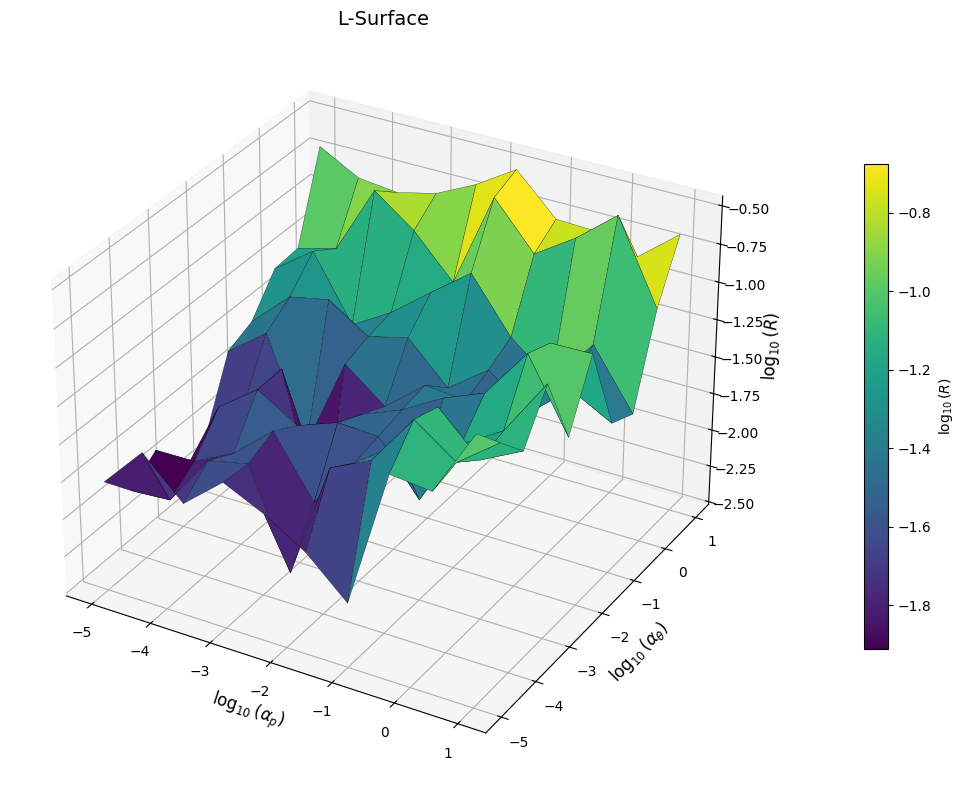

In [15]:
# %%
# ============================================================
# L-SURFACE PLOT
# ============================================================

fig = plt.figure(figsize=(11, 8))

ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(
    X,
    Y,
    Z,
    cmap="viridis",
    edgecolor="k",
    linewidth=0.2,
    antialiased=True
)

ax.set_xlabel(r"$\log_{10}(\alpha_p)$", fontsize=12)
ax.set_ylabel(r"$\log_{10}(\alpha_\theta)$", fontsize=12)
ax.set_zlabel(r"$\log_{10}(R)$", fontsize=12)

ax.set_title("L-Surface", fontsize=14)

fig.colorbar(
    surface,
    ax=ax,
    shrink=0.65,
    pad=0.1,
    label=r"$\log_{10}(R)$"
)

plt.tight_layout()
plt.show()

In [17]:
# %%

df = pd.DataFrame(results)

# ------------------------------------------------------------
# Log quantities
# ------------------------------------------------------------

epsilon = 1e-15

df["log_alpha_p"] = np.log10(df["alpha_p"] + epsilon)
df["log_alpha_theta"] = np.log10(df["alpha_theta"] + epsilon)

df["log_R"] = np.log10(df["misfit"] + epsilon)
df["log_R_p"] = np.log10(df["R_p"] + epsilon)
df["log_R_theta"] = np.log10(df["R_theta"] + epsilon)

df["log_J"] = np.log10(df["objective"] + epsilon)

In [18]:
# %%
# ------------------------------------------------------------
# Corner detection
# ------------------------------------------------------------

reg_total = df["log_R_p"] + df["log_R_theta"]

misfit_norm = (
    (df["log_R"] - df["log_R"].min()) /
    (df["log_R"].max() - df["log_R"].min())
)

reg_norm = (
    (reg_total - reg_total.min()) /
    (reg_total.max() - reg_total.min())
)

df["corner_score"] = np.sqrt(
    misfit_norm**2 +
    reg_norm**2
)

best_index = df["corner_score"].idxmin()

best_row = df.loc[best_index]

print(best_row)

alpha_p                                                         10.0
alpha_theta                                                 0.464159
objective                                                  65.544183
misfit                                                      0.026289
R_p                                                         6.348343
R_theta                                                     4.383122
best_parameters    [0.08981292005246688, 0.00026150291140997206, ...
log_alpha_p                                                      1.0
log_alpha_theta                                            -0.333333
log_R                                                      -1.580218
log_R_p                                                      0.80266
log_R_theta                                                 0.641784
log_J                                                       1.816534
corner_score                                                0.448109
Name: 97, dtype: object


In [19]:
# %%
# ------------------------------------------------------------
# Neighbor selection
# ------------------------------------------------------------

# Distance in parameter space
df["distance"] = np.sqrt(
    (df["log_alpha_p"] - best_row["log_alpha_p"])**2 +
    (df["log_alpha_theta"] - best_row["log_alpha_theta"])**2
)

# Select closest points
neighbors = (
    df.sort_values("distance")
      .head(5)
      .copy()
)

neighbors = neighbors.sort_values(
    by=["log_alpha_p", "log_alpha_theta"]
)

print(neighbors[
    [
        "log_alpha_p",
        "log_alpha_theta",
        "log_R",
        "log_R_theta",
        "log_R_p",
        "log_J",
    ]
])

    log_alpha_p  log_alpha_theta     log_R  log_R_theta   log_R_p     log_J
86     0.333333        -1.000000 -1.359985     0.712534  0.825491  1.175362
87     0.333333        -0.333333 -1.193682     0.653871  0.810856  1.206652
96     1.000000        -1.000000 -1.505046     0.729735  0.783343  1.787386
97     1.000000        -0.333333 -1.580218     0.641784  0.802660  1.816534
98     1.000000         0.333333 -1.014354     0.657920  0.810460  1.872338


In [20]:
# %%
# ------------------------------------------------------------
# Generate LaTeX table
# ------------------------------------------------------------

columns = [
    "log_alpha_p",
    "log_alpha_theta",
    "log_R",
    "log_R_theta",
    "log_R_p",
    "log_J",
]

latex_rows = []

for idx, row in neighbors.iterrows():

    values = [
        f"{row[col]:.6f}"
        for col in columns
    ]

    line = " & ".join(values) + r" \\"

    # Highlight optimal row
    if idx == best_index:

        values_bold = [
            rf"\textbf{{{row[col]:.6f}}}"
            for col in columns
        ]

        line = " & ".join(values_bold) + r" \\"

    latex_rows.append(line)

latex_table = rf"""
\begin{{table}}
\centering
\caption{{
Summary of the regularization path around the optimal region of the L-surface.
The central entry corresponds to the best trade-off between data misfit
and smoothness, according to the L-surface corner.
}}
\label{{tab:lcurve_optimum}}

\begin{{tabular}}{{cccccc}}
\hline
$\log \alpha_{{p}}$
& $\log \alpha_{{\theta}}$
& $\log R$
& $\log R_{{\theta}}$
& $\log R_{{p}}$
& $\log J$
\\
\hline
{chr(10).join(latex_rows)}
\hline
\end{{tabular}}
\end{{table}}
"""

print(latex_table)


\begin{table}
\centering
\caption{
Summary of the regularization path around the optimal region of the L-surface.
The central entry corresponds to the best trade-off between data misfit
and smoothness, according to the L-surface corner.
}
\label{tab:lcurve_optimum}

\begin{tabular}{cccccc}
\hline
$\log \alpha_{p}$
& $\log \alpha_{\theta}$
& $\log R$
& $\log R_{\theta}$
& $\log R_{p}$
& $\log J$
\\
\hline
0.333333 & -1.000000 & -1.359985 & 0.712534 & 0.825491 & 1.175362 \\
0.333333 & -0.333333 & -1.193682 & 0.653871 & 0.810856 & 1.206652 \\
1.000000 & -1.000000 & -1.505046 & 0.729735 & 0.783343 & 1.787386 \\
\textbf{1.000000} & \textbf{-0.333333} & \textbf{-1.580218} & \textbf{0.641784} & \textbf{0.802660} & \textbf{1.816534} \\
1.000000 & 0.333333 & -1.014354 & 0.657920 & 0.810460 & 1.872338 \\
\hline
\end{tabular}
\end{table}

